# Analyse des ventes d’un coffee shop à Avignon

## Contexte

Ce notebook fait partie d’un projet de portfolio data analyst.
Objectif : analyser les ventes journalières d’un coffee shop  à Avignon
sur 2 ans, puis étudier l’impact de la météo sur la demande.

Données utilisées :
- Fichier CSV de ventes journalières (2024–2025)
- Dans un second temps : données météo issues de l’API OpenWeather

Public cible :
- TPE/PME (restauration / coffee shop)
- Recruteurs ou clients souhaitant voir un cas d’usage concret

## Objectifs du notebook

1. Vérifier la qualité des données de ventes (complet, cohérent).
2. Explorer les distributions de ventes, transactions et panier moyen.
3. Analyser les différences semaine vs week-end et saisonnalité simple.
4. Préparer le terrain pour l’ajout des données météo (structure temporelle propre).

In [12]:
# 1. Imports et configuration de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

# 2. Chargement des données de ventes
# Le fichier contient des ventes journalières pour 2024–2025
df = pd.read_csv(r"D:\Users\Utilisateur\Documents\Maryline\Projet perso\Analyse méteo et business\coffee_shop_avignon_sales_2024_2025.csv", parse_dates=["date"])

# 3. Enrichissement avec des variables calendaires
df["day_of_week"] = df["date"].dt.day_name()
df["is_weekend"] = df["date"].dt.weekday >= 5
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

In [14]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            731 non-null    datetime64[ns]
 1   sales_total     731 non-null    float64       
 2   transactions    731 non-null    int64         
 3   average_basket  731 non-null    float64       
 4   day_of_week     731 non-null    object        
 5   is_weekend      731 non-null    bool          
 6   month           731 non-null    int32         
 7   year            731 non-null    int32         
dtypes: bool(1), datetime64[ns](1), float64(2), int32(2), int64(1), object(1)
memory usage: 35.1+ KB


In [16]:
import missingno as msno
from scipy.stats import chi2_contingency
from ydata_profiling import ProfileReport


In [22]:
def analyse_exploratoire(df, nom_dataset="Dataset"):
    print(f"\n==== Analyse Exploratoire : {nom_dataset} ====\n")
    
    # Dimensions
    print("Dimensions :")
    print(df.shape)

    # Types et aperçu
    print("\nTypes des colonnes :")
    print(df.dtypes)
    
    print("\nAperçu du dataset :")
    display(df.head())

    print("\nValeurs manquantes :")
    display(df.isnull().sum())

    print("\nPourcentage de valeurs manquantes :")
    display((df.isnull().mean() * 100).round(2))

    # Unicité colonnes object
    object_cols = df.select_dtypes(include="object").columns
    if len(object_cols) > 0:
        print("\nNombre de valeurs uniques pour les colonnes catégorielles :")
        for col in object_cols:
            print(f"{col} : {df[col].nunique()}")

    # Stats descriptives
    print("\nStatistiques descriptives numériques :")
    display(df.describe().T)

    if len(object_cols) > 0:
        print("\nStatistiques descriptives catégorielles :")
        display(df.describe(include=["object"]).T)

    # Boxplots numériques
    num_cols = df.select_dtypes(include=np.number).columns
    for col in num_cols:
        plt.figure(figsize=(8, 2.5))
        sns.boxplot(x=df[col])
        plt.title(f"Boîte à moustaches - {col}")
        plt.show()

    # Corrélations
    if len(num_cols) > 1:
        plt.figure(figsize=(8, 5))
        corr = df[num_cols].corr()
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
        plt.title("Matrice de corrélation")
        plt.show()

    print("\n==== Fin de l'analyse exploratoire ====")


==== Analyse Exploratoire : Ventes coffee shop Avignon ====

Dimensions :
(731, 8)

Types des colonnes :
date              datetime64[ns]
sales_total              float64
transactions               int64
average_basket           float64
day_of_week               object
is_weekend                  bool
month                      int32
year                       int32
dtype: object

Aperçu du dataset :


,date,sales_total,transactions,average_basket,day_of_week,is_weekend,month,year
0,2024-01-01,399.87,57,7.02,Monday,False,1,2024
1,2024-01-02,374.55,49,7.64,Tuesday,False,1,2024
2,2024-01-03,406.07,52,7.81,Wednesday,False,1,2024
3,2024-01-04,441.17,54,8.17,Thursday,False,1,2024
4,2024-01-05,370.96,54,6.87,Friday,False,1,2024



Valeurs manquantes :


date              0
sales_total       0
transactions      0
average_basket    0
day_of_week       0
is_weekend        0
month             0
year              0
dtype: int64


Pourcentage de valeurs manquantes :


date              0.0
sales_total       0.0
transactions      0.0
average_basket    0.0
day_of_week       0.0
is_weekend        0.0
month             0.0
year              0.0
dtype: float64


Nombre de valeurs uniques pour les colonnes catégorielles :
day_of_week : 7

Statistiques descriptives numériques :


,count,mean,min,25%,50%,75%,max,std
date,731,2024-12-31 00:00:00,2024-01-01 00:00:00,2024-07-01 12:00:00,2024-12-31 00:00:00,2025-07-01 12:00:00,2025-12-31 00:00:00,NaN
sales_total,731.0,441.625294,271.88,399.26,439.28,483.375,671.29,58.315039
transactions,731.0,59.082079,36.0,52.0,58.0,65.0,86.0,8.944814
average_basket,731.0,7.518016,6.46,6.99,7.56,8.02,8.55,0.587839
month,731.0,6.519836,1.0,4.0,7.0,10.0,12.0,3.451913
year,731.0,2024.499316,2024.0,2024.0,2024.0,2025.0,2025.0,0.500342



Statistiques descriptives catégorielles :


,count,unique,top,freq
day_of_week,731,7,Monday,105


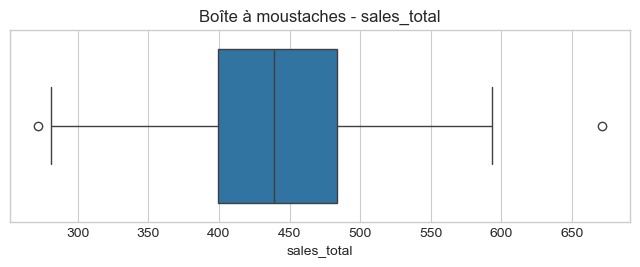

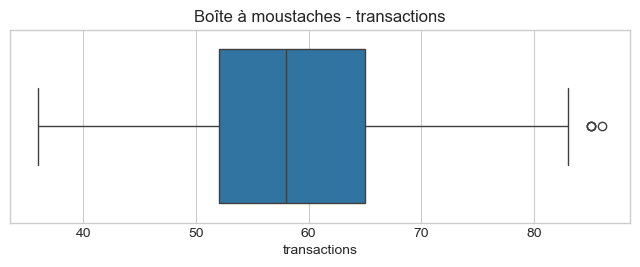

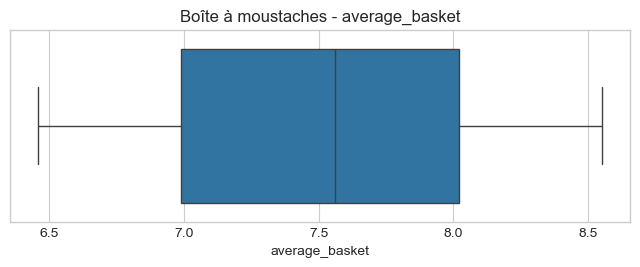

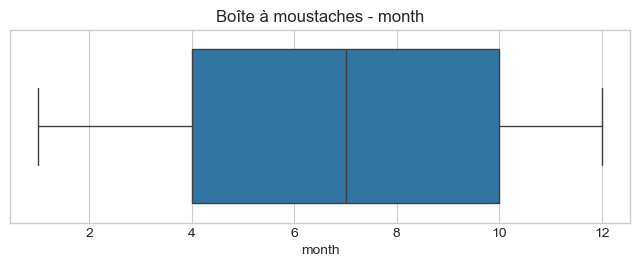

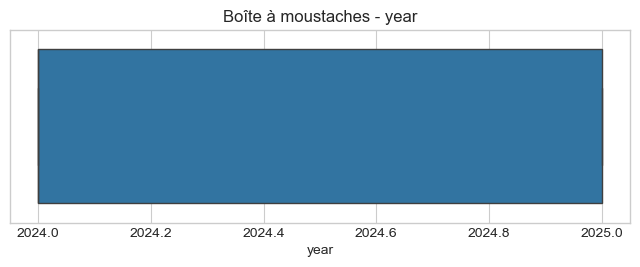

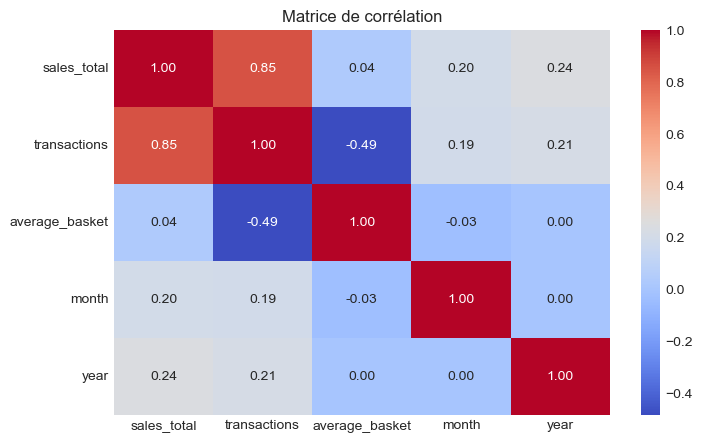


==== Fin de l'analyse exploratoire ====


In [24]:
analyse_exploratoire(df, nom_dataset="Ventes coffee shop Avignon")

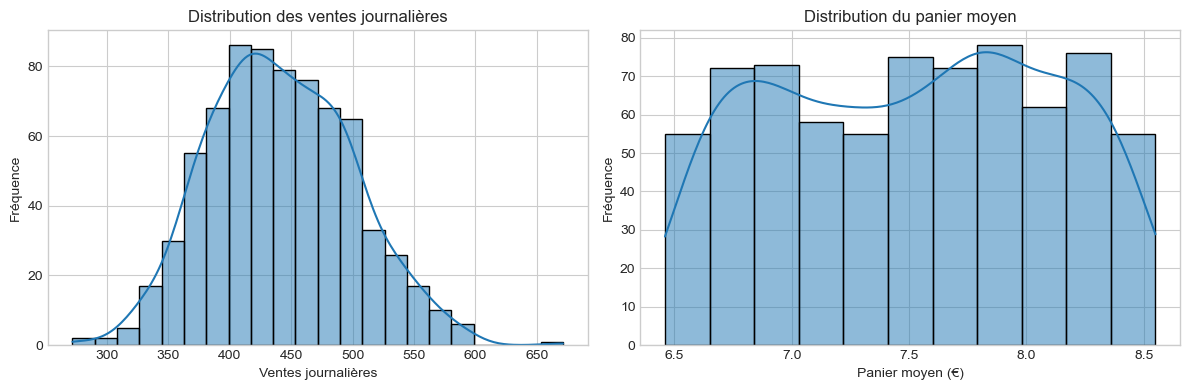

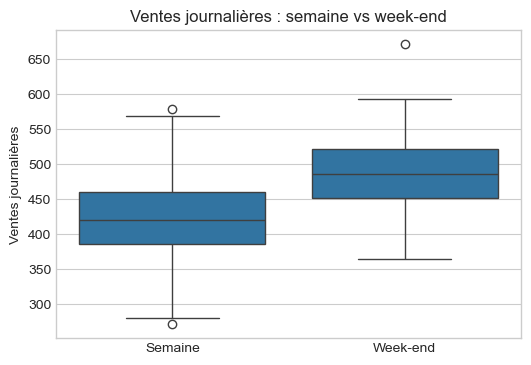

In [26]:
# 4. Distribution des ventes et panier moyen
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["sales_total"], kde=True, ax=axes[0])
axes[0].set_title("Distribution des ventes journalières")
axes[0].set_xlabel("Ventes journalières")
axes[0].set_ylabel("Fréquence")

sns.histplot(df["average_basket"], kde=True, ax=axes[1])
axes[1].set_title("Distribution du panier moyen")
axes[1].set_xlabel("Panier moyen (€)")
axes[1].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

# 5. Ventes semaine vs week-end
plt.figure(figsize=(6, 4))
sns.boxplot(x="is_weekend", y="sales_total", data=df)
plt.xticks([0, 1], ["Semaine", "Week-end"])
plt.title("Ventes journalières : semaine vs week-end")
plt.xlabel("")
plt.ylabel("Ventes journalières")
plt.show()

## Analyse des premières distributions

Les premières visualisations permettent de mieux comprendre la structure globale des ventes du coffee shop.

### Distribution des ventes journalières

L’histogramme des ventes journalières montre une distribution relativement régulière, centrée autour d’un niveau moyen situé approximativement entre 430 € et 470 € par jour.  
La forme de la distribution semble assez proche d’une distribution normale, avec quelques journées plus faibles et quelques journées plus élevées, mais sans concentration extrême sur des valeurs atypiques.

Cette première lecture suggère que l’activité du coffee shop est relativement stable sur la période observée, avec une variabilité modérée d’un jour à l’autre.  
Cela est intéressant pour la suite du projet, car une demande relativement structurée permettra de mieux identifier l’effet de variables externes comme la météo.

### Distribution du panier moyen

La distribution du panier moyen apparaît plus resserrée que celle des ventes totales.  
La majorité des valeurs se situent dans une plage d’environ 6,5 € à 8,5 €, ce qui indique un comportement d’achat assez homogène.

Autrement dit, la variation des ventes journalières semble probablement davantage liée au nombre de transactions qu’à une forte variation du panier moyen.  
Cette hypothèse devra être vérifiée plus loin dans l’analyse, mais elle constitue déjà une piste intéressante pour le modèle futur.

### Comparaison semaine vs week-end

Le boxplot met en évidence un niveau de ventes plus élevé le week-end que pendant la semaine.  
La médiane des ventes journalières est clairement supérieure sur les jours de week-end, ce qui suggère un effet calendrier significatif sur l’activité du coffee shop.

On observe également que la dispersion des ventes reste présente dans les deux groupes, mais le niveau général est décalé vers le haut pour le week-end.  
Cela confirme que la variable `is_weekend` devra être conservée dans les futures analyses explicatives et dans le modèle prédictif.

### Premiers enseignements métier

À ce stade, trois enseignements ressortent :
- l’activité semble relativement stable dans le temps ;
- le panier moyen est assez homogène ;
- le week-end constitue déjà un facteur explicatif fort des ventes.

Ces premiers constats seront utiles pour la suite, notamment pour distinguer ce qui relève d’un effet calendaire classique et ce qui pourrait être expliqué par la météo.

## Préparation des variables météo

Dans la suite du projet, l’objectif est d’enrichir les ventes du coffee shop avec des données météo journalières pour Avignon, afin d’évaluer l’impact du climat sur la demande et de construire un modèle de prévision.

### Variables météo brutes à récupérer

À partir de l’API Open-Meteo, les variables suivantes seront collectées pour chaque date :

- `temp_mean` : température moyenne journalière.
- `temp_min`, `temp_max` : températures minimale et maximale.
- `rain_mm` : cumul de pluie (mm).
- `snow_mm` : cumul de neige (optionnel, mais conservé pour la cohérence).
- `humidity` : humidité moyenne.
- `wind_speed` : vitesse moyenne du vent.
- `clouds` : nébulosité moyenne (0–100).
- `pressure` : pression atmosphérique moyenne (optionnel).
- `weather_main` : type de temps principal (Clear, Clouds, Rain, etc.).
- `weather_description` : description détaillée.

### Variables dérivées météo

Pour rendre ces informations plus interprétables et exploitables dans le modèle, plusieurs variables dérivées seront créées :

- **Pluie**
  - `is_rain` : 1 si `rain_mm > 0`, 0 sinon.
  - `is_heavy_rain` : 1 si `rain_mm` dépasse un seuil (ex. 5 mm).
  - `rain_category` : catégorisation de l’intensité (no_rain / light / moderate / heavy).

- **Température**
  - `temp_bucket` : classes de température (cold / mild / warm / hot) définies à partir de seuils adaptés au climat local.

- **Ensoleillement / couverture nuageuse**
  - `clouds_category` : classes de nébulosité (ensoleillé / nuageux / couvert).

- **Confort météo global**
  - `weather_feel` : indicateur qualitatif combinant température et pluie (par exemple : mauvais / moyen / favorable).

- **Effets de transition**
  - `delta_temp` : variation de température moyenne par rapport à la veille.
  - `delta_rain` : variation du cumul de pluie par rapport à la veille.

Ces variables permettront d’analyser finement la sensibilité des ventes à la météo (par exemple, différence de chiffre d’affaires entre un week-end ensoleillé et un week-end pluvieux) et de les intégrer ensuite dans un modèle de prévision des ventes.

## Récupération des données météo via Open-Meteo

Dans cette étape, l’objectif est d’interroger l’API Open-Meteo afin de récupérer les conditions météo associées à chaque date du jeu de données de ventes.

L’approche retenue repose sur :
- les coordonnées géographiques d’Avignon ;
- une fonction générique d’appel API ;
- une fonction de transformation des réponses JSON en tableau exploitable ;
- une fusion finale avec les données de ventes.

Cette étape permettra ensuite de mesurer l’effet de la météo sur l’activité du coffee shop, puis de construire un modèle de prévision enrichi par les variables climatiques.

In [39]:
# ============================================================
# 1. Imports et paramètres
# ============================================================

import pandas as pd
import requests
import json

LAT = 43.9493
LON = 4.8055

START_DATE = "2024-01-01"
END_DATE = "2025-12-31"

BASE_URL = "https://archive-api.open-meteo.com/v1/archive"

In [41]:
# ============================================================
# 2. Appel API Open-Meteo sécurisé
# ============================================================

params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "precipitation_sum",
        "weather_code",
        "wind_speed_10m_max"
    ],
    "timezone": "Europe/Paris"
}

response = requests.get(BASE_URL, params=params)

print("Status code :", response.status_code)

data = response.json()

print("Clés principales du JSON :")
print(data.keys())

Status code : 200
Clés principales du JSON :
dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])


In [43]:
print(json.dumps(data, indent=2)[:2500])

{
  "latitude": 43.971878,
  "longitude": 4.7799697,
  "generationtime_ms": 189.57781791687012,
  "utc_offset_seconds": 7200,
  "timezone": "Europe/Paris",
  "timezone_abbreviation": "GMT+2",
  "elevation": 29.0,
  "daily_units": {
    "time": "iso8601",
    "temperature_2m_max": "\u00b0C",
    "temperature_2m_min": "\u00b0C",
    "precipitation_sum": "mm",
    "weather_code": "wmo code",
    "wind_speed_10m_max": "km/h"
  },
  "daily": {
    "time": [
      "2024-01-01",
      "2024-01-02",
      "2024-01-03",
      "2024-01-04",
      "2024-01-05",
      "2024-01-06",
      "2024-01-07",
      "2024-01-08",
      "2024-01-09",
      "2024-01-10",
      "2024-01-11",
      "2024-01-12",
      "2024-01-13",
      "2024-01-14",
      "2024-01-15",
      "2024-01-16",
      "2024-01-17",
      "2024-01-18",
      "2024-01-19",
      "2024-01-20",
      "2024-01-21",
      "2024-01-22",
      "2024-01-23",
      "2024-01-24",
      "2024-01-25",
      "2024-01-26",
      "2024-01-27",
   

In [45]:
# ============================================================
# 3. Transformation du JSON en DataFrame
# ============================================================

daily_data = data["daily"]

weather_df = pd.DataFrame({
    "date": pd.to_datetime(daily_data["time"]),
    "temp_max": daily_data["temperature_2m_max"],
    "temp_min": daily_data["temperature_2m_min"],
    "precipitation_sum": daily_data["precipitation_sum"],
    "weather_code": daily_data["weather_code"],
    "wind_speed_max": daily_data["wind_speed_10m_max"]
})

print("Dimensions de weather_df :", weather_df.shape)
display(weather_df.head())
display(weather_df.tail())

Dimensions de weather_df : (731, 6)


,date,temp_max,temp_min,precipitation_sum,weather_code,wind_speed_max
0,2024-01-01,12.3,3.3,0.0,3,17.1
1,2024-01-02,10.1,0.9,0.8,53,10.0
2,2024-01-03,11.6,4.0,0.0,3,14.2
3,2024-01-04,12.1,3.1,0.0,3,12.1
4,2024-01-05,10.2,7.4,11.6,63,29.3


,date,temp_max,temp_min,precipitation_sum,weather_code,wind_speed_max
726,2025-12-27,9.9,1.4,0.0,2,19.1
727,2025-12-28,8.1,1.4,0.0,0,21.6
728,2025-12-29,8.1,-0.8,0.0,2,18.6
729,2025-12-30,2.9,-0.1,0.0,3,42.9
730,2025-12-31,4.0,-0.8,0.0,2,39.5


## Validation des données météo historiques

La récupération des données météo via Open-Meteo a fonctionné correctement.
Le DataFrame `weather_df` contient 731 lignes et 6 colonnes, soit exactement le même nombre de jours que le dataset de ventes.

Les variables récupérées couvrent les principaux indicateurs utiles pour l’analyse :
- températures maximale et minimale,
- cumul de précipitations,
- code météo,
- vitesse maximale du vent.

Les premières observations montrent une météo variée, avec des journées sèches, pluvieuses et venteuses.
Cette diversité est intéressante pour la suite du projet, car elle permettra d’étudier plus finement l’influence des conditions climatiques sur les ventes du coffee shop.

L’étape suivante consiste à fusionner les données de ventes et les données météo sur la colonne `date`, afin de constituer une table analytique unique pour l’exploration et la modélisation.

In [48]:
# ============================================================
# 4. Fusion avec les ventes
# ============================================================

merged_df = df.merge(weather_df, on="date", how="left")

print("Dimensions de merged_df :", merged_df.shape)
display(merged_df.head())
print(merged_df.isnull().sum())

Dimensions de merged_df : (731, 13)


,date,sales_total,transactions,average_basket,day_of_week,is_weekend,month,year,temp_max,temp_min,precipitation_sum,weather_code,wind_speed_max
0,2024-01-01,399.87,57,7.02,Monday,False,1,2024,12.3,3.3,0.0,3,17.1
1,2024-01-02,374.55,49,7.64,Tuesday,False,1,2024,10.1,0.9,0.8,53,10.0
2,2024-01-03,406.07,52,7.81,Wednesday,False,1,2024,11.6,4.0,0.0,3,14.2
3,2024-01-04,441.17,54,8.17,Thursday,False,1,2024,12.1,3.1,0.0,3,12.1
4,2024-01-05,370.96,54,6.87,Friday,False,1,2024,10.2,7.4,11.6,63,29.3


date                 0
sales_total          0
transactions         0
average_basket       0
day_of_week          0
is_weekend           0
month                0
year                 0
temp_max             0
temp_min             0
precipitation_sum    0
weather_code         0
wind_speed_max       0
dtype: int64


## Fusion ventes + météo

La fusion entre les ventes du coffee shop et les données météo d’Open-Meteo a été réalisée sur la colonne `date`.

Le DataFrame final `merged_df` contient :
- 731 lignes, soit deux années complètes de données journalières (2024–2025) ;
- 13 colonnes combinant indicateurs de ventes, variables calendaires et variables météo.

La vérification des valeurs manquantes montre qu’aucune colonne n’est incomplète après fusion.
Cela signifie que chaque jour de ventes dispose bien d’une observation météo associée, ce qui est idéal pour l’analyse de corrélation et la construction d’un modèle de prévision.

À partir de ce tableau unique, il devient possible :
- d’explorer l’impact de la température, de la pluie ou du vent sur les ventes,
- de comparer les comportements semaine vs week-end selon les conditions météo,
- et, dans un second temps, d’entraîner un modèle prédictif intégrant ces variables explicatives.

In [60]:
# ============================================================
# 6. Export des jeux de données au format CSV
# ============================================================

import os

# Dossier de sortie (évite les apostrophes “spéciales” dans le nom)
output_folder = "Analyse_ventes_coffee_shop_Avignon_EDA"

os.makedirs(output_folder, exist_ok=True)

# Export des données météo seules
weather_path = os.path.join(output_folder, "weather_avignon_2024_2025.csv")
weather_df.to_csv(weather_path, index=False)
print(f"Fichier météo exporté : {weather_path}")

# Export des données ventes + météo
merged_path = os.path.join(output_folder, "coffee_shop_avignon_ventes_meteo_2024_2025.csv")
merged_df.to_csv(merged_path, index=False)
print(f"Fichier ventes + météo exporté : {merged_path}")

Fichier météo exporté : Analyse_ventes_coffee_shop_Avignon_EDA\weather_avignon_2024_2025.csv
Fichier ventes + météo exporté : Analyse_ventes_coffee_shop_Avignon_EDA\coffee_shop_avignon_ventes_meteo_2024_2025.csv


## Export des jeux de données

Pour faciliter la réutilisation des données dans les prochains notebooks (modèle prédictif, visualisation, etc.), les tables suivantes sont exportées au format CSV :

- `weather_avignon_2024_2025.csv` : historique météo journalier pour Avignon.
- `coffee_shop_avignon_ventes_meteo_2024_2025.csv` : données de ventes du coffee shop enrichies avec les variables météo.

Ces fichiers serviront de base à la phase de modélisation et à la construction du dashboard.